In [1]:
import model_functions as mf
from get_matrices import get_matrices

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pyvinecopulib as pv

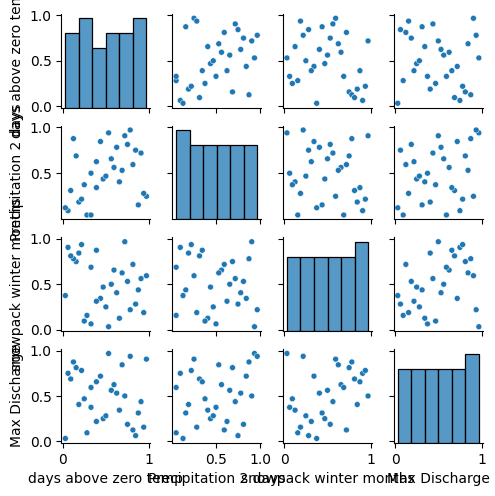

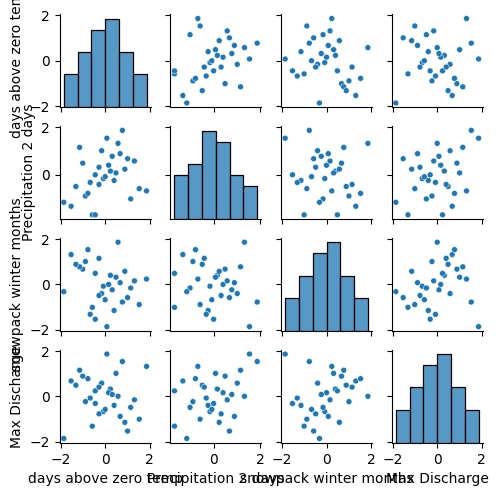

In [2]:
#### import data ####
data = pd.read_csv('..\\Data\\correlation_data.csv', index_col=0)
data.index = pd.to_datetime(data.index)

unity_data = mf.unity(data)
sns.pairplot(unity_data, height=1.25, plot_kws=dict(size=.1))
plt.show()

sd_data = pd.DataFrame(mf.sd_normal(unity_data), columns = data.columns)
sns.pairplot(sd_data, height=1.25,plot_kws=dict(size=.1))
plt.show()

In [3]:
#### Fit using Dismann's ####
vine_model = pv.Vinecop.from_data(unity_data.values)

print(vine_model)

<pyvinecopulib.Vinecop> Vinecop model with 4 variables
tree edge conditioned variables conditioning variables var_types       family rotation       parameters  df   tau 
   1    1                  1, 2                             c, c      Clayton        0             0.74 1.0  0.27 
   1    2                  2, 4                             c, c          Joe        0             1.66 1.0  0.27 
   1    3                  3, 4                             c, c        Frank        0             2.24 1.0  0.24 
   2    1                  1, 4                      2      c, c         Tawn       90 0.30, 0.66, 7.00 3.0 -0.25 
   2    2                  2, 3                      4      c, c Independence                                0.00 
   3    1                  1, 3                   4, 2      c, c Independence                                0.00 



<pyvinecopulib.Vinecop> Vinecop model with 4 variables
tree edge conditioned variables conditioning variables var_types       family rotation       parameters  df   tau 
   1    1                  3, 2                             c, c Independence                                0.00 
   1    2                  2, 4                             c, c          Joe        0             1.66 1.0  0.27 
   1    3                  1, 4                             c, c      Student        0      -0.25, 2.00 2.0 -0.16 
   2    1                  3, 4                      2      c, c         Tawn        0 0.50, 0.47, 6.04 3.0  0.30 
   2    2                  2, 1                      4      c, c         Tawn      180 0.33, 1.00, 4.03 3.0  0.29 
   3    1                  3, 1                   4, 2      c, c Independence                                0.00 



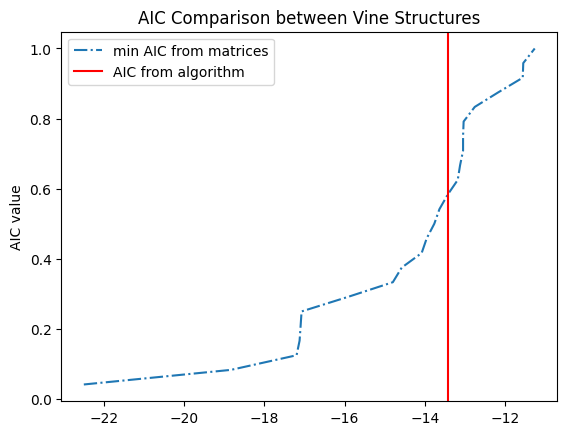

In [4]:
#### fit using Chymera ####
controls = pv.FitControlsVinecop(preselect_families=False)

matrices_4_nodes = get_matrices('./CHIMERA_5/', nodes=4)

#Define a dictionary to store all the models
myDictionary = {} 

#fit vinecop for each matrix and store in dictionary
for i in range(len(matrices_4_nodes)):
    myDictionary.update({str(i): pv.Vinecop.from_data(np.array(unity_data), matrix=matrices_4_nodes[i].matrix)})

vines_AIC = []
for keys in myDictionary:
    vines_AIC.append(myDictionary[keys].aic())

vine_min_aic_index = np.argmin(vines_AIC)
aic_ecdf = mf.ecdf(vines_AIC)
algo_aic = vine_model.aic()

plt.plot(aic_ecdf[0], aic_ecdf[1], label='min AIC from matrices', linestyle='-.')
plt.axvline(x=algo_aic, color='r', linestyle='-', label='AIC from algorithm')
plt.ylabel('AIC value')
plt.title('AIC Comparison between Vine Structures')
plt.legend()
plt.savefig('..//Figures//AIC_comparison.png', dpi=300)

min_aic_index = vines_AIC.index(min(vines_AIC))
vine_min_aic = myDictionary[list(myDictionary.keys())[min_aic_index]] #regular vine with the lowest AIC
vine_min_aic.matrix
print(vine_min_aic)

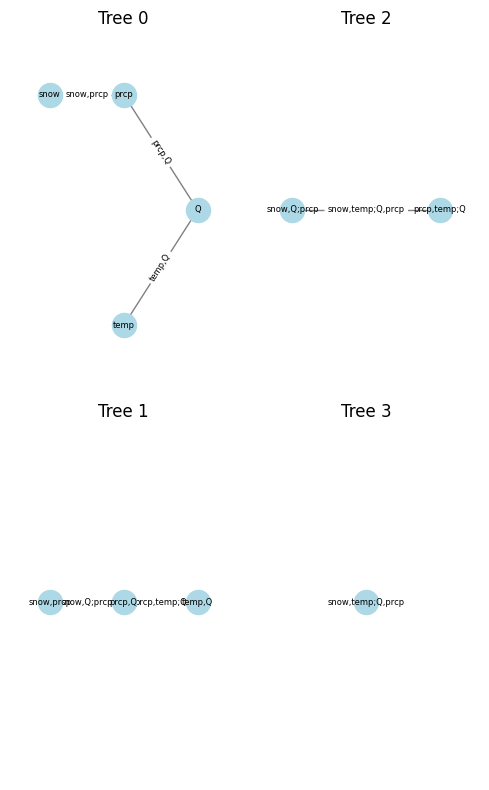

In [5]:
#### Plot the best model ####
vine_min_aic.plot(layout='graphviz', tree=[0, 1, 2, 3], vars_names=['temp', 'prcp', 'snow', 'Q'])
# plt.savefig('..//Figures//Vine_min_AIC.png', dpi=300)

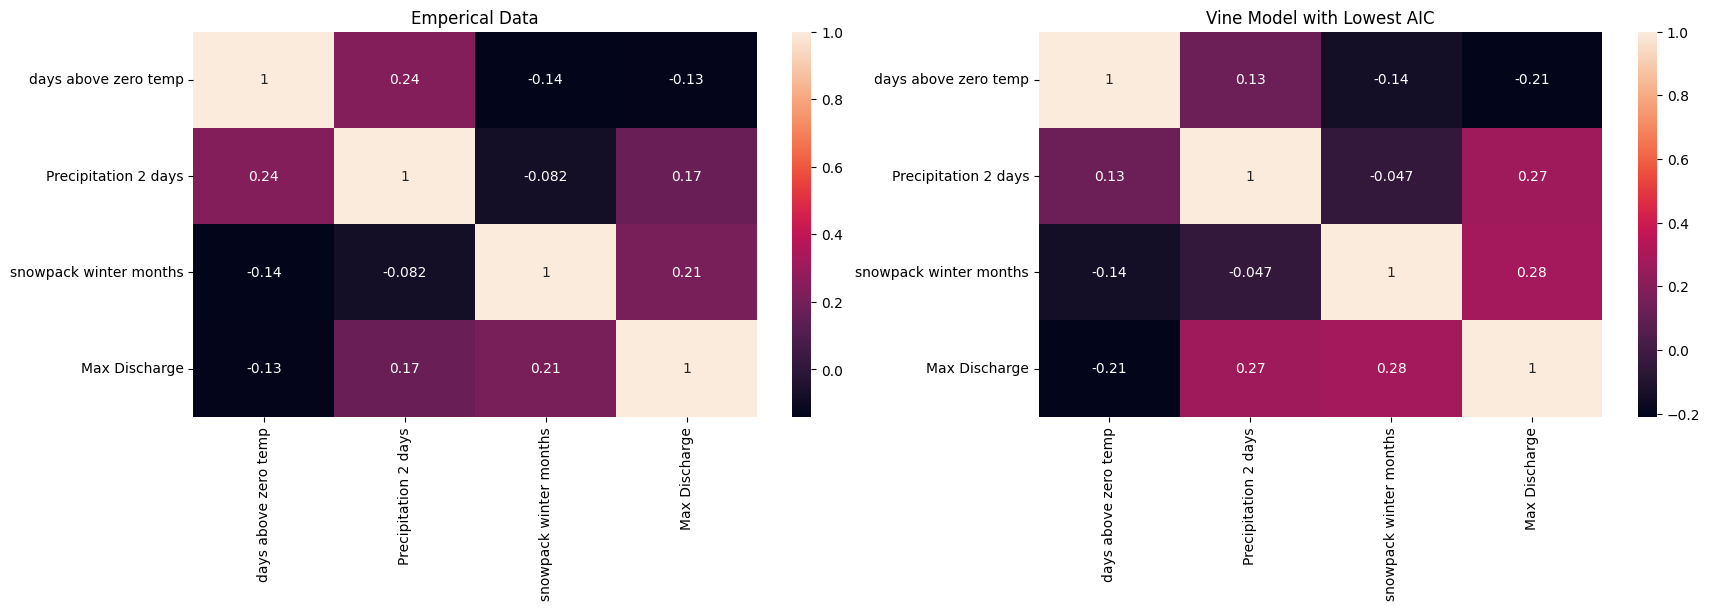

In [6]:
#### Goodness of fit assesment ####
fig, axes = plt.subplots(1,2, figsize=(20,5))

uvs_min_aic = vine_min_aic.simulate(500)

unity_data = pd.DataFrame(unity_data, columns=data.columns)
uvs_min_aic = pd.DataFrame(uvs_min_aic, columns=data.columns)

sns.heatmap(unity_data.corr(method = 'kendall'), annot=True, ax=axes[0])
axes[0].set_title('Emperical Data')

sns.heatmap(uvs_min_aic.corr(method = 'kendall'), annot=True, ax=axes[1])
axes[1].set_title('Vine Model with Lowest AIC')

plt.savefig('..\\Figures\\kendall_correlation_matrices.png', bbox_inches='tight', dpi=300)

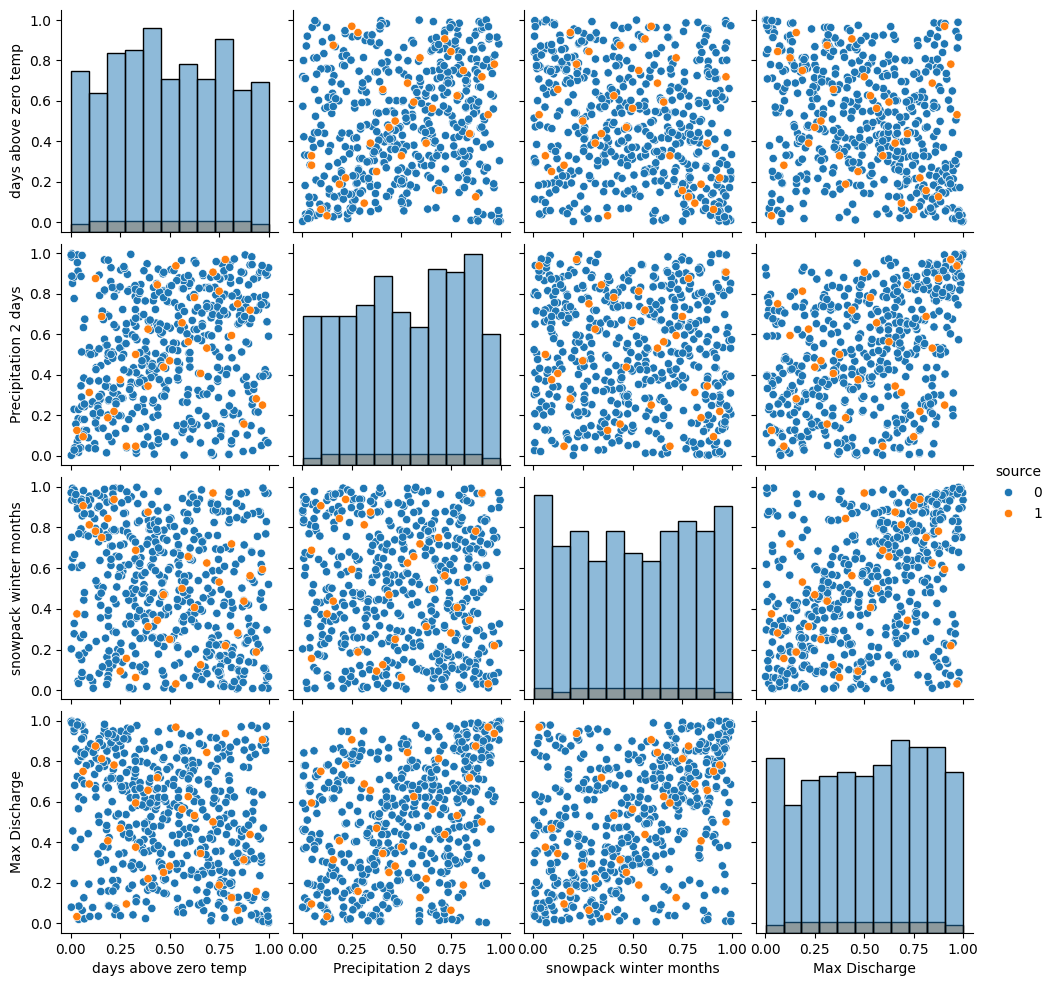

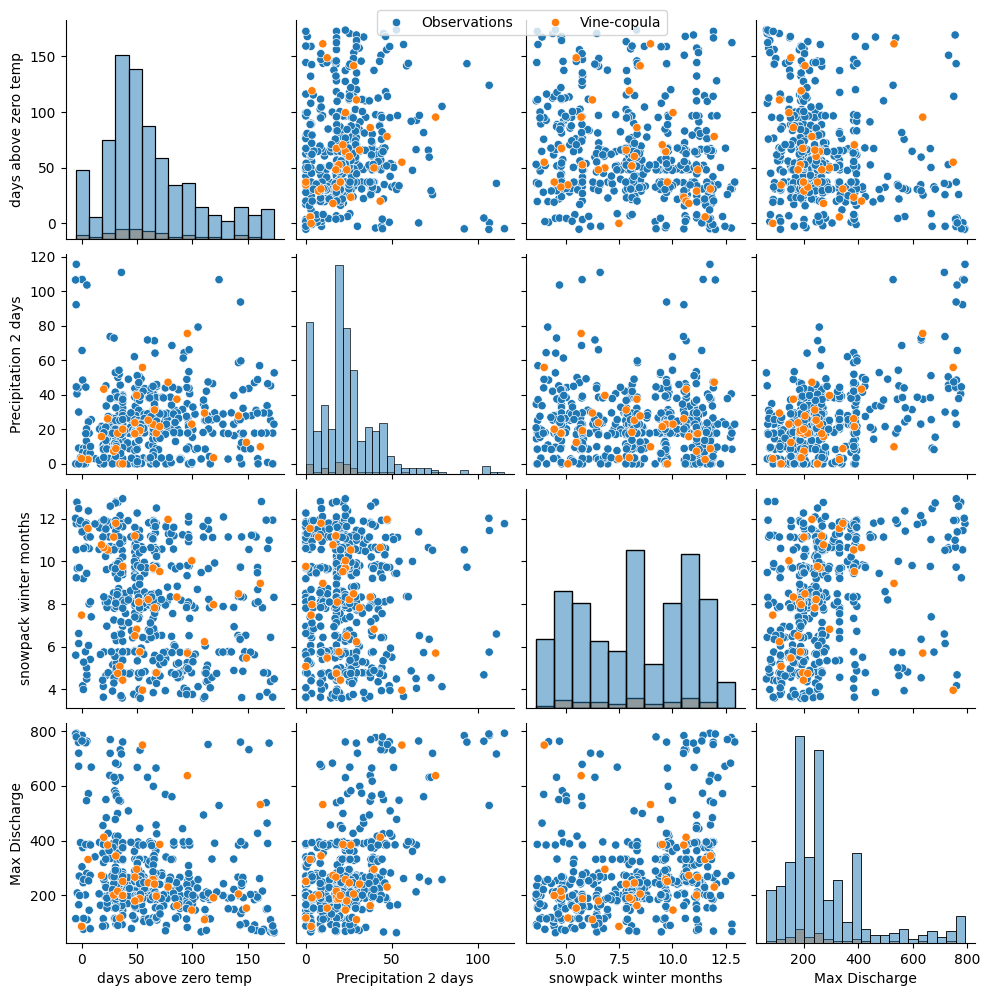

In [7]:
data_unity = unity_data.copy()
data_unity['source'] = 1
samples_unity = pd.DataFrame(uvs_min_aic, columns=unity_data.columns)
samples_unity['source'] = 0
data_unity['source'] = 1
concat = pd.concat([samples_unity, data_unity], ignore_index=True)

g = sns.pairplot(concat, hue="source", diag_kind="hist")

rv_together = [mf.eval_inverse_ecdf(data.iloc[:, col], concat.iloc[:, col]) for col in range(len(concat.columns)-1)]
rv_together=pd.DataFrame(np.transpose(rv_together))
rv_together['source']=concat['source']
rv_together.columns = concat.columns
g = sns.pairplot(data = pd.DataFrame(rv_together), hue="source", diag_kind="hist")
g._legend.set_title(None)
new_labels = ['Observations', 'Vine-copula']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

sns.move_legend(g, "upper center" ,ncol=2, frameon=True, bbox_to_anchor = (0.5,1))
plt.savefig('..\\Figures\\pairplot_vine_vs_data.png', dpi=300)

In [ ]:
#### Use the best model to simulate discharge values conditional on the other variables ####

### Takes a while (about 5 mins) ###

result = data.copy()
result['simulated mean'] = 0.0
result['simulated std'] = 0.0
result['simulated 5%'] = 0.0
result['simulated 95%'] = 0.0
result.index = data.index.year

years = result.index
for year in years:
    # print(f"Processing year: {year}\n")
    temp = result.loc[year, "days above zero temp"]
    prcp = result.loc[year, "Precipitation 2 days"]
    snow = result.loc[year, "snowpack winter months"]
    results = mf.conditionalize(data, vine_min_aic, [0, 1, 2], [temp, prcp, snow], tol=0.01, n_samples=10**6)
    results = pd.DataFrame(results.T, columns=['Max Discharge'])
    results_old = pd.read_csv(f"samples/samples_{year}.csv", usecols=['Max Discharge'])
    results_old = results_old[results_old['Max Discharge'] > 0]
    results = pd.concat([results_old, results], ignore_index=True)
    results.to_csv(f"samples/samples_{year}.csv")
    results.dropna(inplace=True)
    results = results[results['Max Discharge'] > 0]
    if len(results) > 3 and results.shape[1] == 1:
        result.loc[year, 'simulated mean'] = np.mean(results)
        result.loc[year, 'simulated std'] = results[results.columns[0]].std()
        result.loc[year, 'simulated 5%'] = results[results.columns[0]].quantile(0.05)
        result.loc[year, 'simulated 95%'] = results[results.columns[0]].quantile(0.95)

c:\Users\max\miniconda3\envs\CEGM2005_pybanshee\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\max\miniconda3\envs\CEGM2005_pybanshee\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
c:\Users\max\miniconda3\envs\CEGM2005_pybanshee\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\max\miniconda3\envs\CEGM2005_pybanshee\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


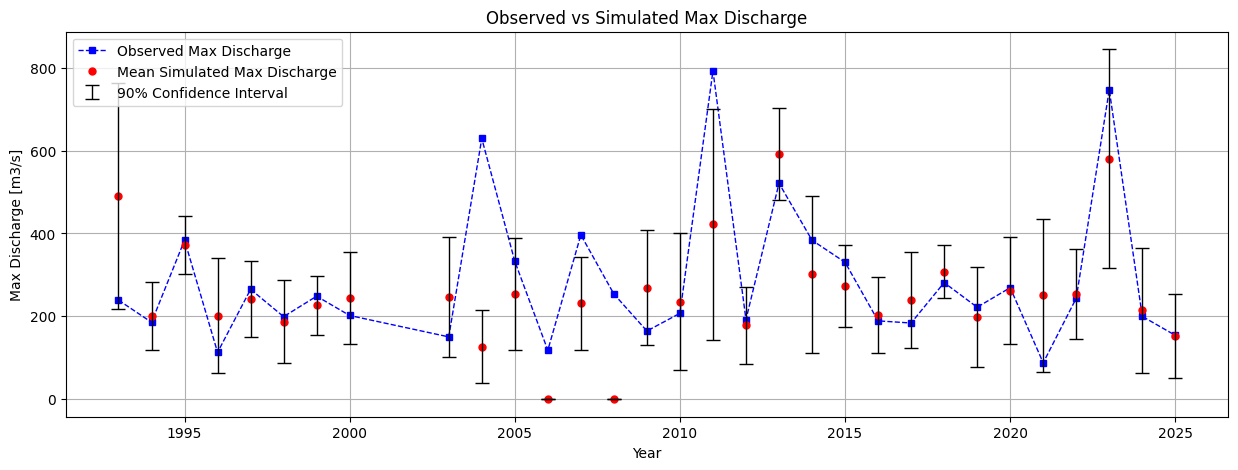

In [9]:
#### Plot observed vs simulated max discharge ####
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(result.index, result['Max Discharge'], ls='--', marker='s', label='Observed Max Discharge', markersize=5, color = 'blue', linewidth=1)
ax.plot(result.index, result['simulated mean'], ls='none', marker='o', color='red', label='Mean Simulated Max Discharge', markersize=5)

error = result["simulated 95%"] - result["simulated 5%"]
ax.errorbar(result.index, result['simulated mean'], yerr=error/2, fmt='none', ecolor='black', capsize=5, label='90% Confidence Interval', linewidth=1)
# ax.fill_between(result.index, result['simulated 5%'], result['simulated 95%'], color='gray', alpha=0.3, label='90% Confidence Interval')
ax.set_xlabel('Year')
ax.grid()
ax.legend()

ax.set_ylabel('Max Discharge [m3/s]')
ax.set_title('Observed vs Simulated Max Discharge')

plt.savefig('..\\Figures\\observed_vs_simulated_max_discharge.png', dpi=300)